###Importing Required Libraries

In [ ]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Import Label Encoder and train_test_split, gridsearchcv
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_val_score

# for min_max scaling
from sklearn.preprocessing import MinMaxScaler

# Import models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor

# Import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
data = pd.read_csv('D:\SIT720\distinction_task\melb_data.csv')
df = data.copy()
# Observe the 5 rows
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [30]:
# Number of Rows, Columns
df.shape

(13580, 21)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [32]:
# Memory usage statistics for each columns
df.memory_usage()


Index               132
Suburb           108640
Address          108640
Rooms            108640
Type             108640
Price            108640
Method           108640
SellerG          108640
Date             108640
Distance         108640
Postcode         108640
Bedroom2         108640
Bathroom         108640
Car              108640
Landsize         108640
BuildingArea     108640
YearBuilt        108640
CouncilArea      108640
Lattitude        108640
Longtitude       108640
Regionname       108640
Propertycount    108640
dtype: int64

Exploratory Data Analysis

In [33]:
# Select columns with data type 'object'
columns_to_convert = df.select_dtypes(include=['object']).columns

# Apply the mask to select the columns and convert object columns to categorical 
# to get advantage for memory usage, performance and better semantics.
df[columns_to_convert] = df[columns_to_convert].astype('category')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Suburb         13580 non-null  category
 1   Address        13580 non-null  category
 2   Rooms          13580 non-null  int64   
 3   Type           13580 non-null  category
 4   Price          13580 non-null  float64 
 5   Method         13580 non-null  category
 6   SellerG        13580 non-null  category
 7   Date           13580 non-null  category
 8   Distance       13580 non-null  float64 
 9   Postcode       13580 non-null  float64 
 10  Bedroom2       13580 non-null  float64 
 11  Bathroom       13580 non-null  float64 
 12  Car            13518 non-null  float64 
 13  Landsize       13580 non-null  float64 
 14  BuildingArea   7130 non-null   float64 
 15  YearBuilt      8205 non-null   float64 
 16  CouncilArea    12211 non-null  category
 17  Lattitude      13580 non-null  

In [35]:
# Memory usage statistics for each columns after convert data types
df.memory_usage()

Index               132
Suburb            37968
Address          662608
Rooms            108640
Type              13712
Price            108640
Method            13792
SellerG           37600
Date              16148
Distance         108640
Postcode         108640
Bedroom2         108640
Bathroom         108640
Car              108640
Landsize         108640
BuildingArea     108640
YearBuilt        108640
CouncilArea       14916
Lattitude        108640
Longtitude       108640
Regionname        13944
Propertycount    108640
dtype: int64

In [36]:
# Summary Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rooms,13580.0,2.937997e+00,0.955748,1.00000,2.000000,3.000000,3.000000e+00,1.000000e+01
Price,13580.0,1.075684e+06,639310.724296,85000.00000,650000.000000,903000.000000,1.330000e+06,9.000000e+06
Distance,13580.0,1.013778e+01,5.868725,0.00000,6.100000,9.200000,1.300000e+01,4.810000e+01
Postcode,13580.0,3.105302e+03,90.676964,3000.00000,3044.000000,3084.000000,3.148000e+03,3.977000e+03
Bedroom2,13580.0,2.914728e+00,0.965921,0.00000,2.000000,3.000000,3.000000e+00,2.000000e+01
Bathroom,13580.0,1.534242e+00,0.691712,0.00000,1.000000,1.000000,2.000000e+00,8.000000e+00
Car,13518.0,1.610075e+00,0.962634,0.00000,1.000000,2.000000,2.000000e+00,1.000000e+01
Landsize,13580.0,5.584161e+02,3990.669241,0.00000,177.000000,440.000000,6.510000e+02,4.330140e+05
BuildingArea,7130.0,1.519676e+02,541.014538,0.00000,93.000000,126.000000,1.740000e+02,4.451500e+04
YearBuilt,8205.0,1.964684e+03,37.273762,1196.00000,1940.000000,1970.000000,1.999000e+03,2.018000e+03


In [37]:
# Correlation Analysis
df.corr(numeric_only=True).T

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
Rooms,1.000000,0.496634,0.294203,0.055303,0.944190,0.592934,0.408483,0.025678,0.124127,-0.065413,0.015948,0.100771,-0.081530
Price,0.496634,1.000000,-0.162522,0.107867,0.475951,0.467038,0.238979,0.037507,0.090981,-0.323617,-0.212934,0.203656,-0.042153
Distance,0.294203,-0.162522,1.000000,0.431514,0.295927,0.127155,0.262994,0.025004,0.099481,0.246379,-0.130723,0.239425,-0.054910
Postcode,0.055303,0.107867,0.431514,1.000000,0.060584,0.113664,0.050289,0.024558,0.055475,0.032863,-0.406104,0.445357,0.062304
Bedroom2,0.944190,0.475951,0.295927,0.060584,1.000000,0.584685,0.405325,0.025646,0.122319,-0.053319,0.015925,0.102238,-0.081350
Bathroom,0.592934,0.467038,0.127155,0.113664,0.584685,1.000000,0.322246,0.037130,0.111933,0.152702,-0.070594,0.118971,-0.052201
Car,0.408483,0.238979,0.262994,0.050289,0.405325,0.322246,1.000000,0.026770,0.096101,0.104515,-0.001963,0.063395,-0.024295
Landsize,0.025678,0.037507,0.025004,0.024558,0.025646,0.037130,0.026770,1.000000,0.500485,0.036451,0.009695,0.010833,-0.006854
BuildingArea,0.124127,0.090981,0.099481,0.055475,0.122319,0.111933,0.096101,0.500485,1.000000,0.019665,0.043420,-0.023810,-0.028840
YearBuilt,-0.065413,-0.323617,0.246379,0.032863,-0.053319,0.152702,0.104515,0.036451,0.019665,1.000000,0.060445,-0.003470,0.006361


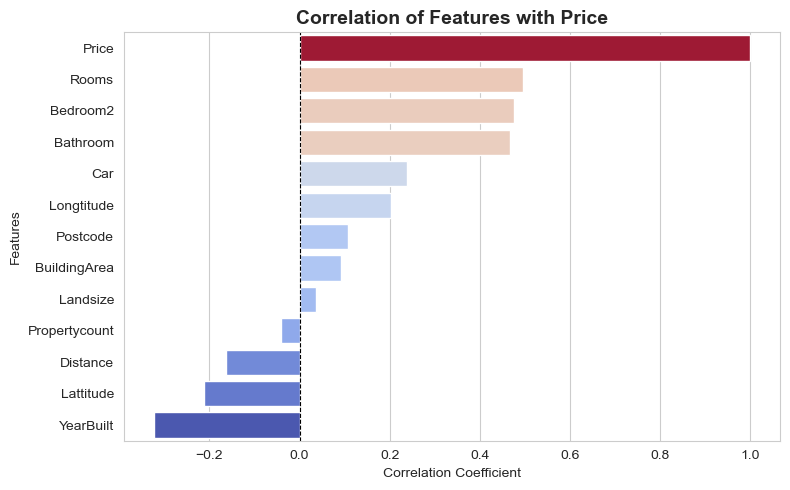

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlations
corr_with_price = df.corrwith(df["Price"], numeric_only=True).sort_values(ascending=False)

# Set the style
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# Plot horizontal bar chart
sns.barplot(
    x=corr_with_price.values,
    y=corr_with_price.index,
    palette="coolwarm",
    hue=corr_with_price.values,  # adds color meaning based on value
    dodge=False,
    legend=False
)

# Add title and labels
plt.title("Correlation of Features with Price", fontsize=14, weight="bold")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')  # vertical line at 0
plt.tight_layout()

plt.show()


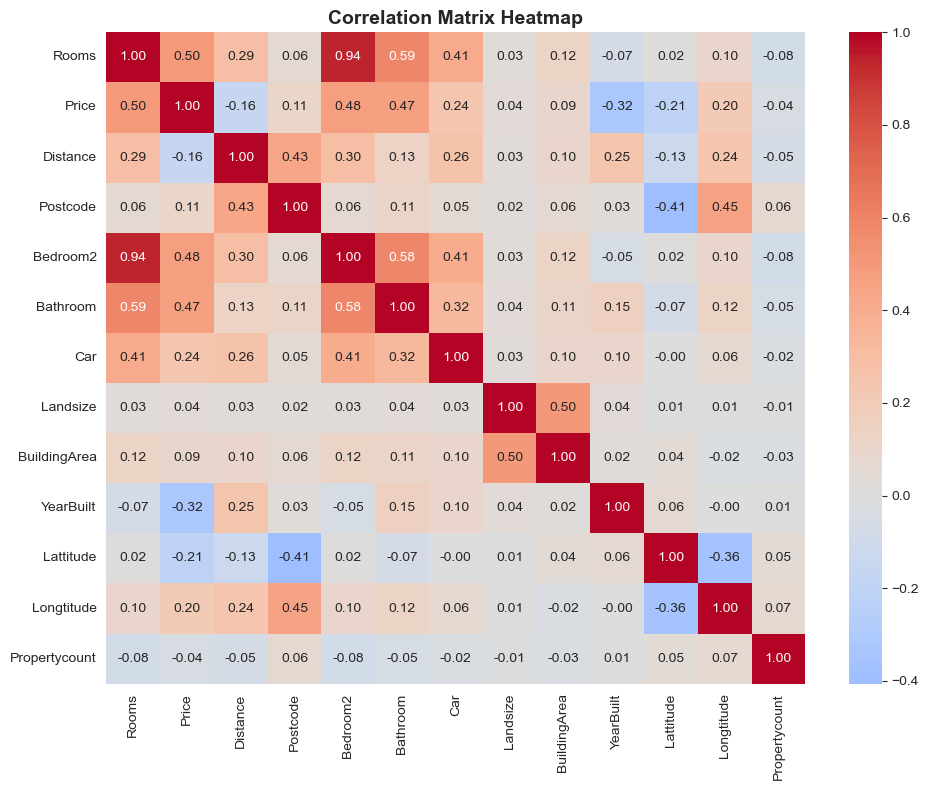

In [39]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation Matrix Heatmap", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


In [40]:
# Count the number of missing data
df.isna().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

In [41]:
# Check duplicate rows
df[df.duplicated()]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount


In [42]:
# Delete duplicates
df.drop_duplicates(inplace=True)

In [43]:
# Checking unique values of categorical columns
categorical_columns = df.select_dtypes(include=['category']).columns

for column in categorical_columns:
    unique_values = df[column].unique()
    print(f'Column "{column}" unique values: {unique_values}')

Column "Suburb" unique values: ['Abbotsford', 'Airport West', 'Albert Park', 'Alphington', 'Altona', ..., 'Attwood', 'Wallan', 'New Gisborne', 'Plumpton', 'Monbulk']
Length: 314
Categories (314, object): ['Abbotsford', 'Aberfeldie', 'Airport West', 'Albanvale', ..., 'Wyndham Vale', 'Yallambie', 'Yarra Glen', 'Yarraville']
Column "Address" unique values: ['85 Turner St', '25 Bloomburg St', '5 Charles St', '40 Federation La', '55a Park St', ..., '12 Strada Cr', '77 Merrett Dr', '83 Power St', '96 Verdon St', '6 Agnes St']
Length: 13378
Categories (13378, object): ['1 Adelle Ct', '1 Airlie St', '1 Albion Ct', '1 Alexander St', ..., '9a Ivan Av', '9a Russell St', '9a The Crossway', '9b Stewart St']
Column "Type" unique values: ['h', 'u', 't']
Categories (3, object): ['h', 't', 'u']
Column "Method" unique values: ['S', 'SP', 'PI', 'VB', 'SA']
Categories (5, object): ['PI', 'S', 'SA', 'SP', 'VB']
Column "SellerG" unique values: ['Biggin', 'Nelson', 'Jellis', 'Greg', 'LITTLE', ..., 'Area', 'S

###Remove Outliers using Z-score Method

In [44]:
numerical_columns = df.select_dtypes(exclude="category").columns

z_score_threshold = 3

for col in numerical_columns:
    z_scores = (df[col] - df[col].mean())/df[col].std()
    outliers = (z_scores < -z_score_threshold) | (z_scores > z_score_threshold)
    print("Outlier counts of column:", col, df[col][outliers].count())
    #df[col]=df[col][~outliers]
    df[col][outliers] = np.nan # replace with nan

Outlier counts of column: Rooms 86
Outlier counts of column: Price 232
Outlier counts of column: Distance 246
Outlier counts of column: Postcode 162
Outlier counts of column: Bedroom2 99
Outlier counts of column: Bathroom 143
Outlier counts of column: Car 138
Outlier counts of column: Landsize 24
Outlier counts of column: BuildingArea 4
Outlier counts of column: YearBuilt 6
Outlier counts of column: Lattitude 139
Outlier counts of column: Longtitude 174
Outlier counts of column: Propertycount 359


C:\Users\user\AppData\Local\Temp\ipykernel_14396\1793096115.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[col][outliers] = np.nan # replace with nan
C:\Users\user\AppData\Local\Temp\ipykernel_14396\1793096115.py:10: SettingWithCopy

Filling Missing Values

In [45]:
df.isna().sum()

Suburb              0
Address             0
Rooms              86
Type                0
Price             232
Method              0
SellerG             0
Date                0
Distance          246
Postcode          162
Bedroom2           99
Bathroom          143
Car               200
Landsize           24
BuildingArea     6454
YearBuilt        5381
CouncilArea      1369
Lattitude         139
Longtitude        174
Regionname          0
Propertycount     359
dtype: int64

In [46]:
# Remove features that has a very weak correlation with price, address is not necessary
df.drop(columns=["Postcode", "Lattitude", "Longtitude", "Propertycount"], inplace=True)

In [47]:
df.isna().sum()


Suburb             0
Address            0
Rooms             86
Type               0
Price            232
Method             0
SellerG            0
Date               0
Distance         246
Bedroom2          99
Bathroom         143
Car              200
Landsize          24
BuildingArea    6454
YearBuilt       5381
CouncilArea     1369
Regionname         0
dtype: int64

In [48]:
# Fill the missing values of Bathroom and Car with mode
df['Bathroom'].fillna(df['Bathroom'].mode()[0], inplace=True)
df['Car'].fillna(df['Car'].mode()[0], inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_14396\3643893421.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Bathroom'].fillna(df['Bathroom'].mode()[0], inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_14396\3643893421.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

In [49]:
# Check the common value of Bedroom2 by grouping Rooms and Type
df[["Rooms", "Type","Bedroom2"]].groupby(["Type","Rooms"]).agg(pd.Series.mode)

C:\Users\user\AppData\Local\Temp\ipykernel_14396\2717691185.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[["Rooms", "Type","Bedroom2"]].groupby(["Type","Rooms"]).agg(pd.Series.mode)


Bedroom2
Type Rooms          
h    1.0         1.0
     2.0         2.0
     3.0         3.0
     4.0         4.0
     5.0         5.0
t    1.0         1.0
     2.0         2.0
     3.0         3.0
     4.0         4.0
     5.0         5.0
u    1.0         1.0
     2.0         2.0
     3.0         3.0
     4.0         4.0
     5.0         NaN

In [50]:
# Replace missing room values with Bedroom2 if any.
missing_room_idx=df.loc[df["Rooms"].isna()]["Rooms"].index.tolist()

for i in missing_room_idx:
    df.loc[i, "Rooms"] = df._get_value(i, "Bedroom2")

In [51]:
# Delete the remaining rows with missing room and drop Bedroom2
df.dropna(axis=0, subset="Rooms", inplace=True)
df.drop(columns=["Bedroom2"], inplace=True)

In [52]:
df.isna().sum()

Suburb             0
Address            0
Rooms              0
Type               0
Price            228
Method             0
SellerG            0
Date               0
Distance         244
Bathroom           0
Car                0
Landsize          24
BuildingArea    6418
YearBuilt       5347
CouncilArea     1359
Regionname         0
dtype: int64

In [53]:
# Find max distance of houses by grouping YearBuilt.
grouped_yearBuilt_by_distance=df[["Distance", "YearBuilt"]].groupby("YearBuilt").max()

# Since distance and yearbuilt have a strong correlation with each other than the others, 
# we can replace missing null distance values with checking same yearbuilt.
for k1, v1 in df[df["Distance"].isna()][["Distance", "YearBuilt"]].iterrows():
    for year, val in grouped_yearBuilt_by_distance.iterrows():
        if(v1["YearBuilt"] == year):
            df.at[k1, "Distance"] = val["Distance"]

In [54]:
# Check remaining missing values
df.isna().sum()

Suburb             0
Address            0
Rooms              0
Type               0
Price            228
Method             0
SellerG            0
Date               0
Distance          87
Bathroom           0
Car                0
Landsize          24
BuildingArea    6418
YearBuilt       5347
CouncilArea     1359
Regionname         0
dtype: int64

In [55]:
# Check missing CouncilArea rows.
df.loc[df["CouncilArea"].isna()]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Regionname
7584,Brighton East,7 Roberts Ct,3.0,h,1270000.0,VB,Ray,20/05/2017,10.7,1.0,3.0,724.0,NaN,NaN,NaN,Southern Metropolitan
10797,Reservoir,48 Crevelli St,3.0,h,526250.0,SP,Barry,8/07/2017,12.0,1.0,1.0,308.0,NaN,NaN,NaN,Northern Metropolitan
12213,Aberfeldie,1 Alma St,4.0,h,1436000.0,S,Brad,3/09/2017,7.5,3.0,3.0,511.0,187.0,1922.0,NaN,Western Metropolitan
12214,Albion,40 Ridley St,5.0,h,905000.0,S,hockingstuart,3/09/2017,10.5,2.0,3.0,732.0,NaN,1925.0,NaN,Western Metropolitan
12215,Alphington,22 Harker St,4.0,h,1680000.0,S,Love,3/09/2017,5.7,3.0,2.0,720.0,NaN,NaN,NaN,Northern Metropolitan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4.0,h,1245000.0,S,Barry,26/08/2017,16.7,2.0,2.0,652.0,NaN,1981.0,NaN,South-Eastern Metropolitan
13576,Williamstown,77 Merrett Dr,3.0,h,1031000.0,SP,Williams,26/08/2017,6.8,2.0,2.0,333.0,133.0,1995.0,NaN,Western Metropolitan
13577,Williamstown,83 Power St,3.0,h,1170000.0,S,Raine,26/08/2017,6.8,2.0,4.0,436.0,NaN,1997.0,NaN,Western Metropolitan
13578,Williamstown,96 Verdon St,4.0,h,2500000.0,PI,Sweeney,26/08/2017,6.8,1.0,2.0,866.0,157.0,1920.0,NaN,Western Metropolitan


In [56]:
# Check remaining missing values
df.isna().sum()

Suburb             0
Address            0
Rooms              0
Type               0
Price            228
Method             0
SellerG            0
Date               0
Distance          87
Bathroom           0
Car                0
Landsize          24
BuildingArea    6418
YearBuilt       5347
CouncilArea     1359
Regionname         0
dtype: int64

In [57]:
# Remove all rows that has missing val in Distance
# Yearbuilt has a lot of missing values so it will be discarded
# Address is not necessary because of suburb and regionname features
# Date is not necessary
df.dropna(axis=0, subset="Distance", inplace=True)
df.drop(["Address", "YearBuilt", "Date"],axis=1,inplace=True)

In [58]:
# Find mean price of houses by grouping Rooms and Regionname 
grouped_price=df[["Price", "Rooms", "Regionname"]].groupby(["Rooms", "Regionname"]).agg("mean")

# Replace missing null price with others in same regionname and same room numbers
for k1, v1 in df[df["Price"].isna()].iterrows():
    for k2, v2 in grouped_price.iterrows():
        if(v1["Rooms"] == k2[0] and v1["Regionname"] == k2[1]):
            df.at[k1, "Price"] = v2["Price"]

C:\Users\user\AppData\Local\Temp\ipykernel_14396\158378630.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_price=df[["Price", "Rooms", "Regionname"]].groupby(["Rooms", "Regionname"]).agg("mean")


In [59]:
# Check remaining missing values
df.isna().sum()

Suburb             0
Rooms              0
Type               0
Price              0
Method             0
SellerG            0
Distance           0
Bathroom           0
Car                0
Landsize          20
BuildingArea    6337
CouncilArea     1331
Regionname         0
dtype: int64

In [60]:
# Drop missing all rows in Price
df.dropna(axis=0, subset="Price", inplace=True)

In [61]:
# Check remaining missing values
df.isna().sum()

Suburb             0
Rooms              0
Type               0
Price              0
Method             0
SellerG            0
Distance           0
Bathroom           0
Car                0
Landsize          20
BuildingArea    6337
CouncilArea     1331
Regionname         0
dtype: int64

In [62]:
# Drop missing all rows in Price
df.dropna(axis=0, subset="CouncilArea", inplace=True)

In [63]:
# Check remaining missing values
df.isna().sum()

Suburb             0
Rooms              0
Type               0
Price              0
Method             0
SellerG            0
Distance           0
Bathroom           0
Car                0
Landsize          18
BuildingArea    5679
CouncilArea        0
Regionname         0
dtype: int64

In [64]:
# Drop missing all rows in Price
df.dropna(axis=0, subset="Landsize", inplace=True)

In [65]:
# Check remaining missing values
df.isna().sum()

Suburb             0
Rooms              0
Type               0
Price              0
Method             0
SellerG            0
Distance           0
Bathroom           0
Car                0
Landsize           0
BuildingArea    5668
CouncilArea        0
Regionname         0
dtype: int64

In [66]:
df.dropna(axis=0, subset="BuildingArea", inplace=True)

In [67]:
# Final data
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 6400 entries, 1 to 12209
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Suburb        6400 non-null   category
 1   Rooms         6400 non-null   float64 
 2   Type          6400 non-null   category
 3   Price         6400 non-null   float64 
 4   Method        6400 non-null   category
 5   SellerG       6400 non-null   category
 6   Distance      6400 non-null   float64 
 7   Bathroom      6400 non-null   float64 
 8   Car           6400 non-null   float64 
 9   Landsize      6400 non-null   float64 
 10  BuildingArea  6400 non-null   float64 
 11  CouncilArea   6400 non-null   category
 12  Regionname    6400 non-null   category
dtypes: category(6), float64(7)
memory usage: 472.7 KB


In [68]:
df.columns


Index(['Suburb', 'Rooms', 'Type', 'Price', 'Method', 'SellerG', 'Distance',
       'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'CouncilArea',
       'Regionname'],
      dtype='object')

###Data visualisation

📍 Categorical Columns – Count Plots

C:\Users\user\AppData\Local\Temp\ipykernel_14396\147648259.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\user\AppData\Local\Temp\ipykernel_14396\147648259.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\user\AppData\Local\Temp\ipykernel_14396\147648259.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\user\AppData\Local\Temp\ipykernel_14396\147648259.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue

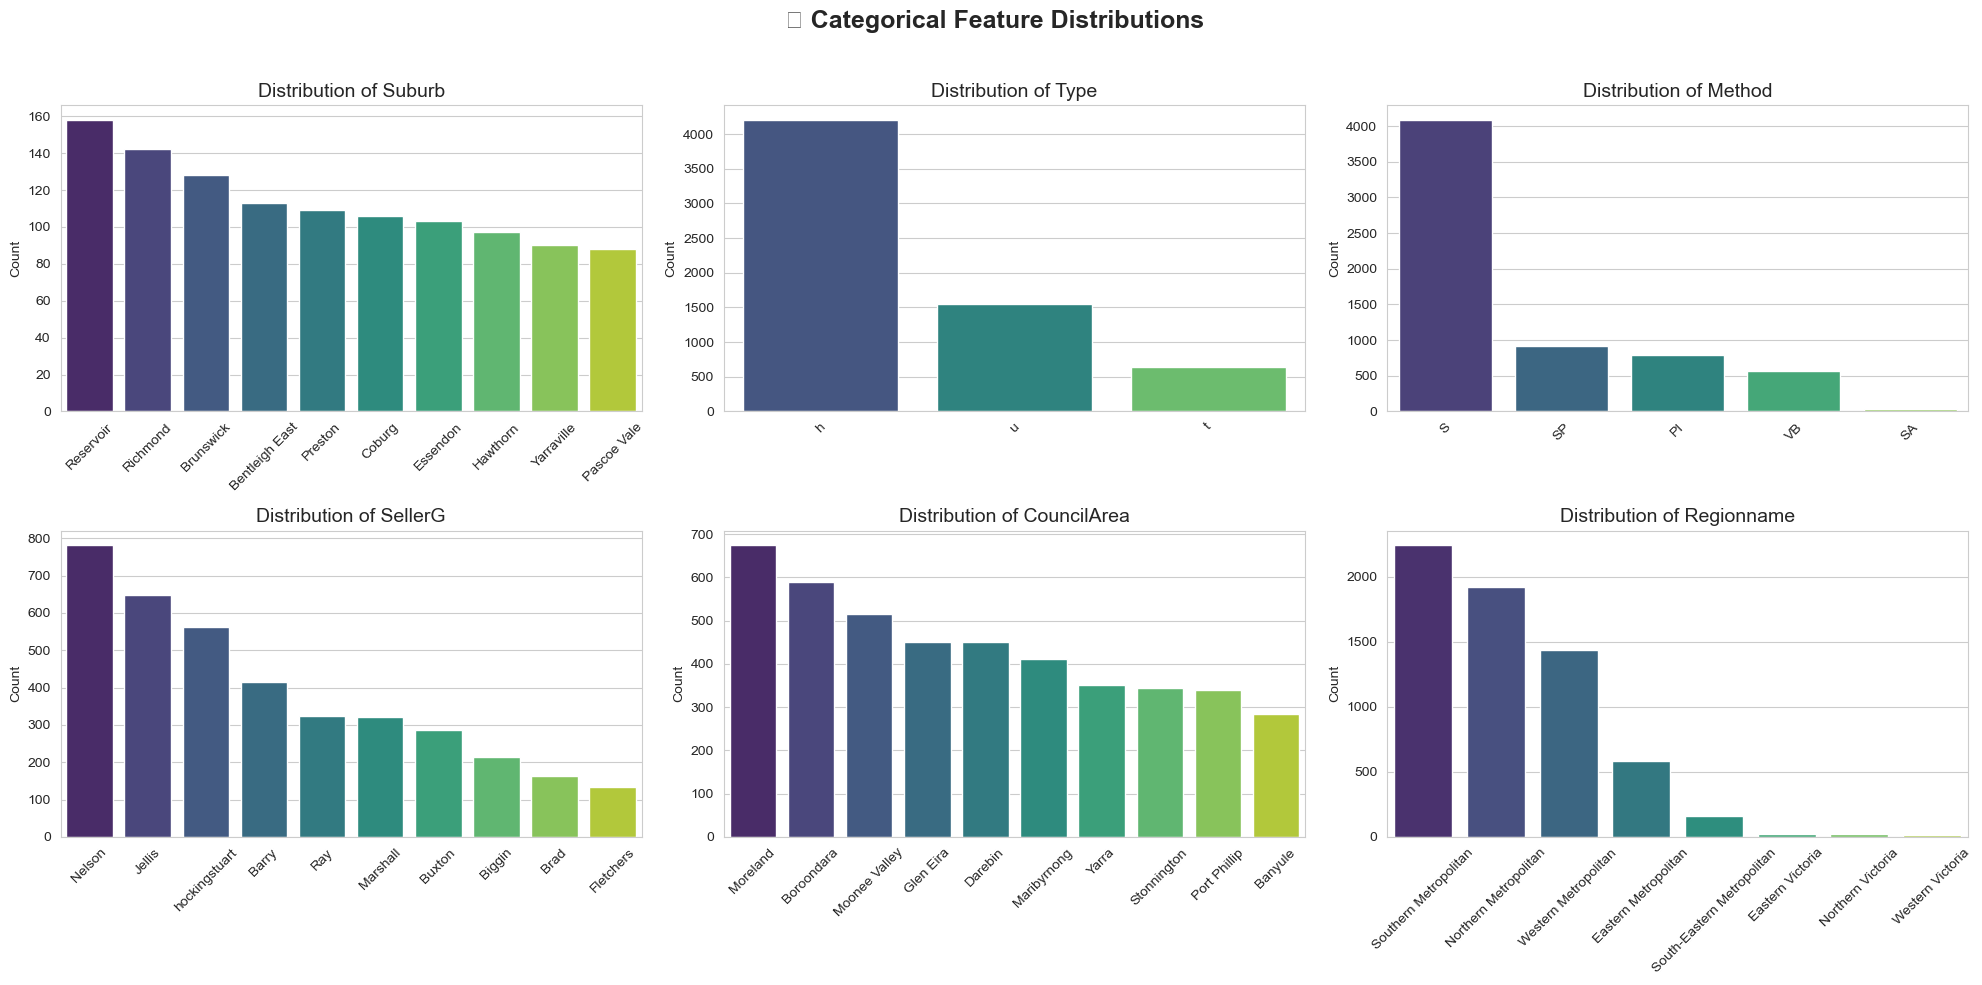

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Suburb', 'Type', 'Method', 'SellerG', 'CouncilArea', 'Regionname']

# Define layout: e.g., 2 rows × 3 columns
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
fig.suptitle("📊 Categorical Feature Distributions", fontsize=18, weight="bold")

# Flatten axes for easy iteration
axes = axes.flatten()

# Loop through each categorical column and plot
for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index[:10],  # Top 10 categories
        ax=axes[i],
        palette="viridis"
    )
    axes[i].set_title(f"Distribution of {col}", fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# Remove empty subplots (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for title
plt.show()



C:\Users\user\AppData\Local\Temp\ipykernel_14396\3090856031.py:25: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for main title
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


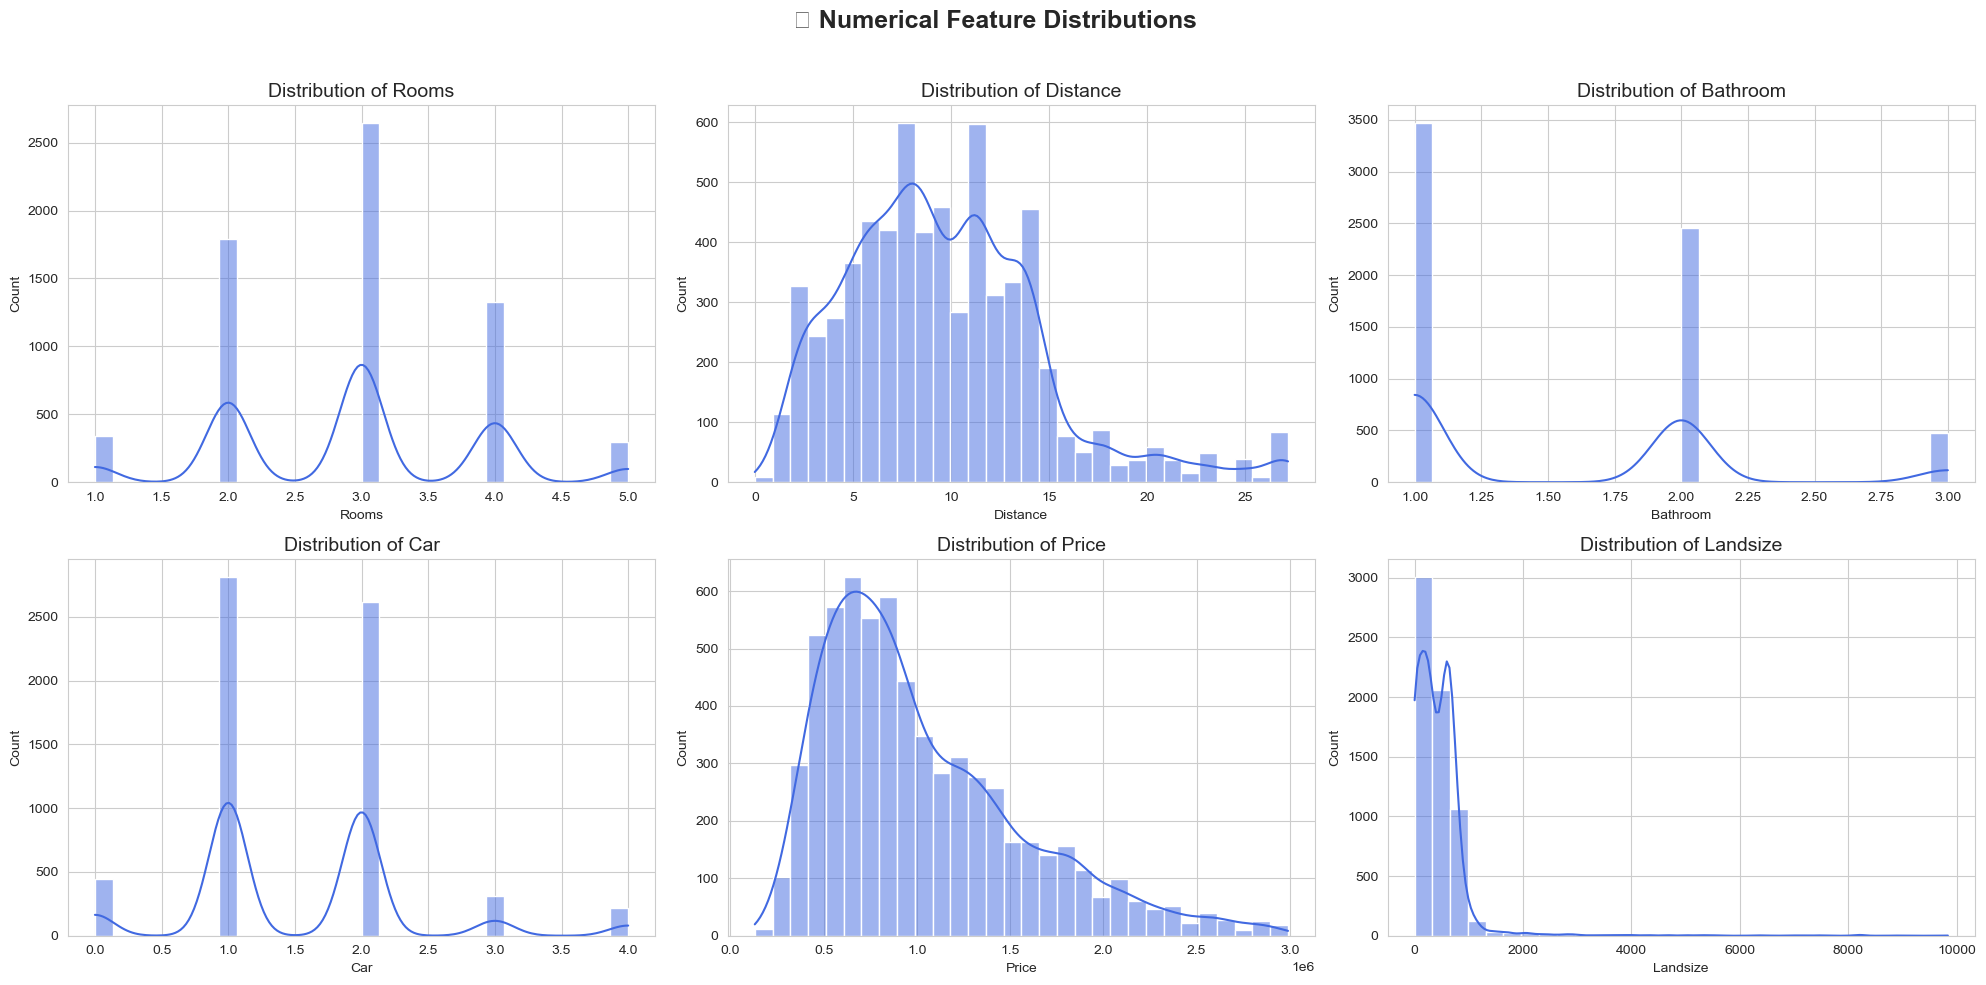

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Rooms', 'Distance', 'Bathroom', 'Car','Price','Landsize']

# Create a figure with 2 rows × 3 columns (since we have 6 numerical columns)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
fig.suptitle("📈 Numerical Feature Distributions", fontsize=18, weight="bold")

# Flatten axes for easy looping
axes = axes.flatten()

# Plot each histogram
for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, kde=True, bins=30, ax=axes[i], color='royalblue')
    axes[i].set_title(f"Distribution of {col}", fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Remove any unused subplots (in case you have fewer columns)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for main title
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_14396\855643142.py:24: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


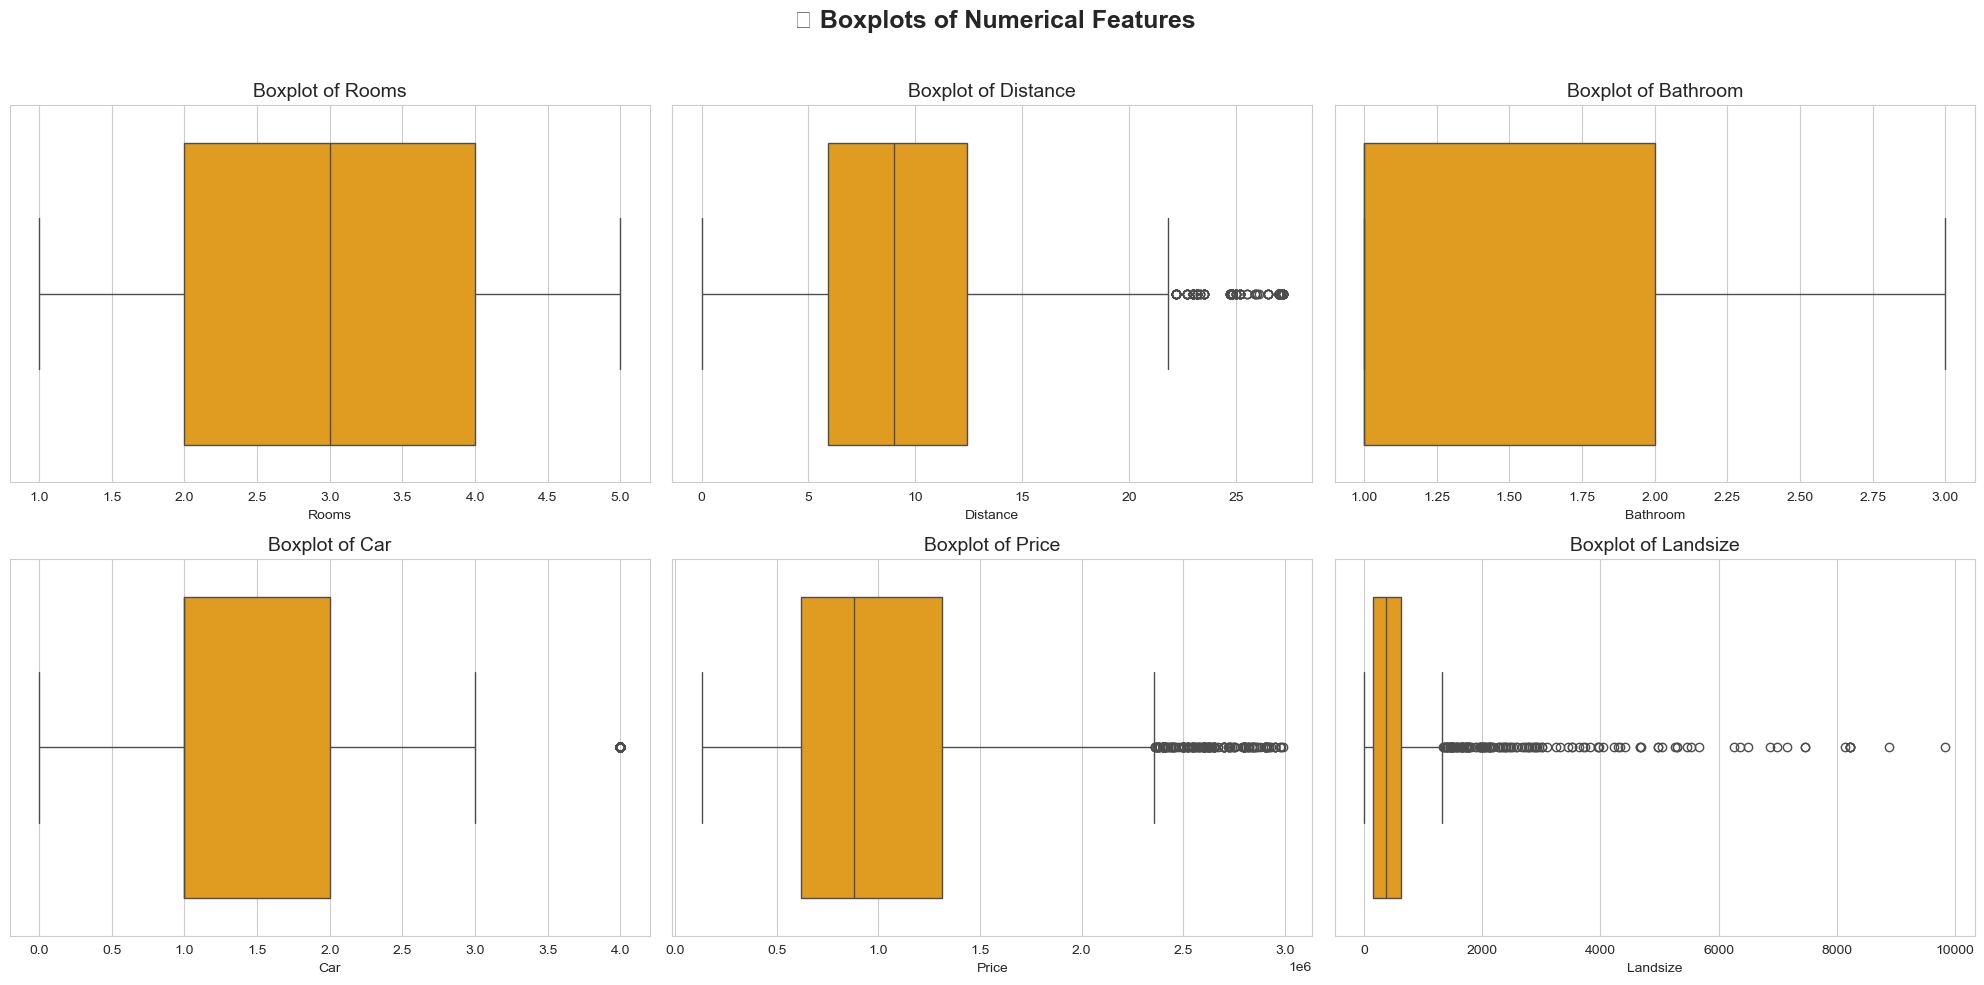

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Price','Landsize']

# Create a figure with 2 rows × 3 columns
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
fig.suptitle("📦 Boxplots of Numerical Features", fontsize=18, weight="bold")

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot each boxplot
for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x=col, ax=axes[i], color='orange')
    axes[i].set_title(f"Boxplot of {col}", fontsize=14)
    axes[i].set_xlabel(col)

# Remove unused axes (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



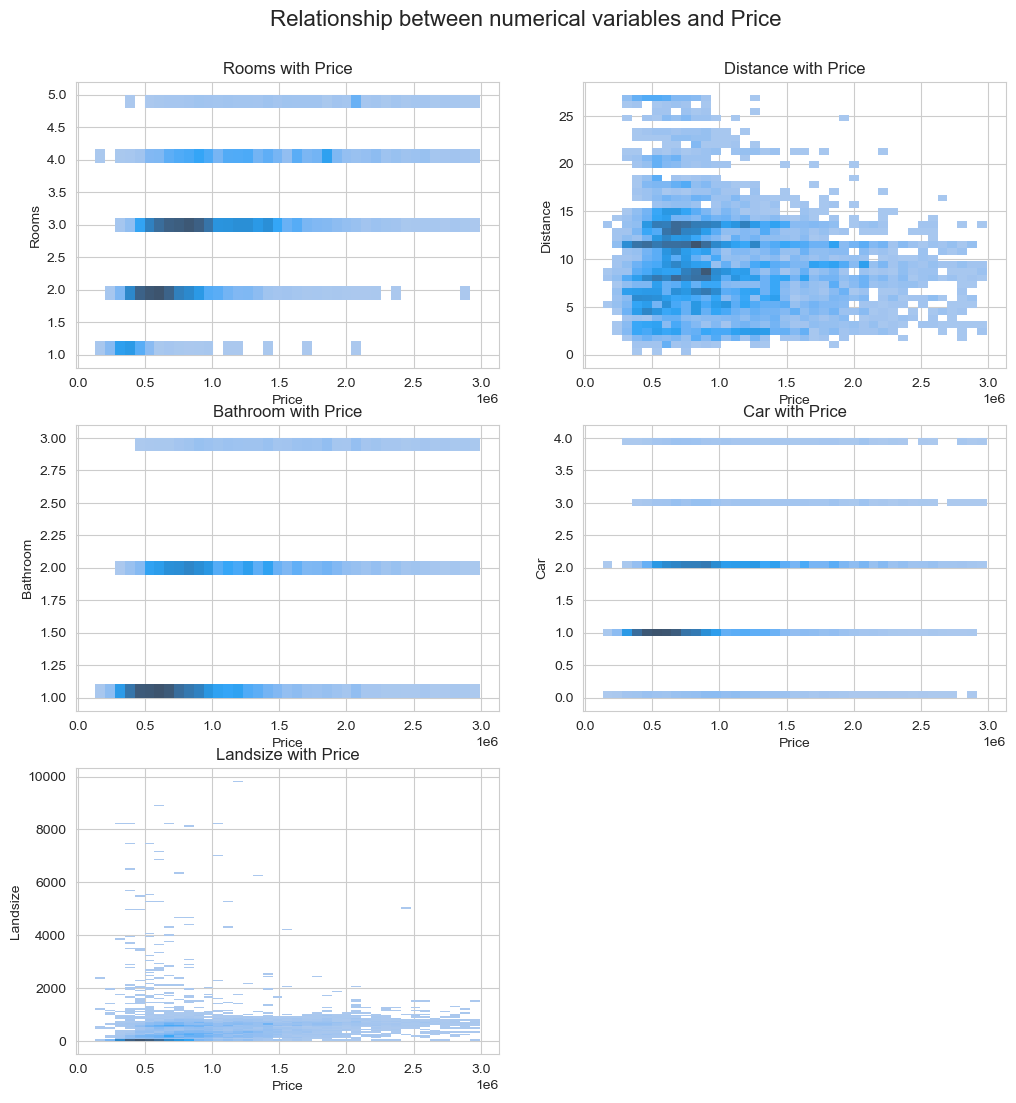

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create 3x2 subplot grid
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
plt.subplots_adjust(top=0.92)
fig.suptitle('Relationship between numerical variables and Price', fontsize=16)

# Plot each variable vs Price
sns.histplot(ax=axes[0,0], data=df, x="Price", y="Rooms")
axes[0,0].set_title('Rooms with Price')

sns.histplot(ax=axes[0,1], data=df, x="Price", y="Distance")
axes[0,1].set_title('Distance with Price')

sns.histplot(ax=axes[1,0], data=df, x="Price", y="Bathroom")
axes[1,0].set_title('Bathroom with Price')

sns.histplot(ax=axes[1,1], data=df, x="Price", y="Car")
axes[1,1].set_title('Car with Price')

sns.histplot(ax=axes[2,0], data=df, x="Price", y="Landsize")
axes[2,0].set_title('Landsize with Price')

# Hide the last empty subplot (axes[2,1])
axes[2,1].axis('off')

# Save figure
plt.savefig('relationship_with_price.png')
plt.show()


<Axes: >

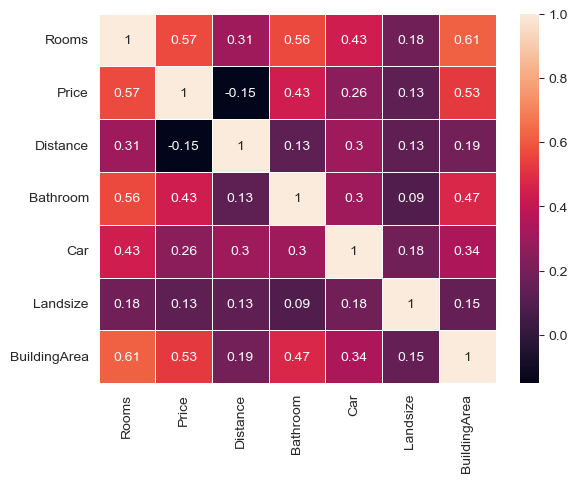

In [77]:

# Correlation Matrix
sns.heatmap(df.corr(numeric_only=True).T, annot=True, linewidths=.5)

In [78]:
df.head()

,Suburb,Rooms,Type,Price,Method,SellerG,Distance,Bathroom,Car,Landsize,BuildingArea,CouncilArea,Regionname
1,Abbotsford,2.0,h,1035000.0,S,Biggin,2.5,1.0,0.0,156.0,79.0,Yarra,Northern Metropolitan
2,Abbotsford,3.0,h,1465000.0,SP,Biggin,2.5,2.0,0.0,134.0,150.0,Yarra,Northern Metropolitan
4,Abbotsford,4.0,h,1600000.0,VB,Nelson,2.5,1.0,2.0,120.0,142.0,Yarra,Northern Metropolitan
6,Abbotsford,3.0,h,1876000.0,S,Nelson,2.5,2.0,0.0,245.0,210.0,Yarra,Northern Metropolitan
7,Abbotsford,2.0,h,1636000.0,S,Nelson,2.5,1.0,2.0,256.0,107.0,Yarra,Northern Metropolitan


###Onehot-Encoding

In [80]:
# Define features and target variable
X = df.drop('Price', axis=1)
y = df['Price']


In [81]:
 #Define numeric and categorical columns
numeric_columns = ['Rooms', 'Distance', 'Bathroom','Car','Landsize','BuildingArea']
categorical_columns = ['Suburb','SellerG', 'Type','Method', 'Regionname','CouncilArea']

In [82]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=123)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
    ]
)

# Define models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=123),
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=123)
}

saved_model_pipeline = None  # placeholder to save Gradient Boosting

# Train and evaluate each model
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Fit model
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_val)
    
    # Metrics
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)
    
    # Results
    print(f"📊 {name} Results:")
    print(f"   - Mean Squared Error (MSE): {mse:.4f}")
    print(f"   - Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"   - R² Score: {r2:.4f}")
    print("-" * 50)
    

📊 Random Forest Results:
   - Mean Squared Error (MSE): 56522398201.9588
   - Root Mean Squared Error (RMSE): 237744.3968
   - R² Score: 0.8126
--------------------------------------------------
📊 Linear Regression Results:
   - Mean Squared Error (MSE): 71768170020.6966
   - Root Mean Squared Error (RMSE): 267895.8193
   - R² Score: 0.7620
--------------------------------------------------
📊 Ridge Regression Results:
   - Mean Squared Error (MSE): 69509023337.2332
   - Root Mean Squared Error (RMSE): 263645.6397
   - R² Score: 0.7695
--------------------------------------------------
📊 Gradient Boosting Results:
   - Mean Squared Error (MSE): 59729713535.3223
   - Root Mean Squared Error (RMSE): 244396.6316
   - R² Score: 0.8019
--------------------------------------------------


In [83]:
import os
import joblib

# Define the folder and file path
save_folder = r"D:\SIT720\distinction_task\model"
os.makedirs(save_folder, exist_ok=True)  # Create folder if it doesn't exist
save_path = os.path.join(save_folder, "gradient_boosting_model.pkl")

# Inside your training loop, save Gradient Boosting
if name == 'Gradient Boosting':
    saved_model_pipeline = pipeline
    joblib.dump(saved_model_pipeline, save_path)
    print(f"✅ Gradient Boosting model saved as '{save_path}'")


✅ Gradient Boosting model saved as 'D:\SIT720\distinction_task\model\gradient_boosting_model.pkl'


In [88]:
import pandas as pd
import joblib

# Path to the saved Gradient Boosting model
model_path = r"D:\SIT720\distinction_task\model\gradient_boosting_model.pkl"

# Load the pipeline
loaded_pipeline = joblib.load(model_path)

# Example input data (replace with your actual feature values)
input_data = {
    'Rooms': 3,
    'Distance': 10,
    'Bathroom': 2,
    'Car': 2,
    'Landsize': 159.0,
    'BuildingArea': 150,
    'Method':'S',
    'SellerG':'Ray',
    'Suburb': 'Abbotsford',
    'Type': 'h',
    'Regionname': 'Northern Metropolitan',
    'CouncilArea':'Yarra'
}

# Convert the dictionary into a DataFrame
input_df = pd.DataFrame([input_data])

# Make predictions
predictions = loaded_pipeline.predict(input_df)

# Display the predictions
print(f"Predicted Housing Price: {predictions[0]:.2f}")


Writing housing_app_app.py


In [86]:
# Make predictions using the loaded pipeline
predictions = loaded_pipeline.predict(input_df)

# Format the predictions for better readability
formatted_predictions = ["${:,.0f}".format(prediction) for prediction in predictions]

print(f"Predicted Price: {prediction}")

Predicted Price: $798,507


In [91]:
import pandas as pd

data = pd.read_csv('D:\SIT720\distinction_task\melb_data.csv')

unique_suburbs = data['Suburb'].unique()
print(unique_suburbs)

unique_suburbs = data['Regionname'].unique()
print(unique_suburbs)

['Abbotsford' 'Airport West' 'Albert Park' 'Alphington' 'Altona'
 'Altona North' 'Armadale' 'Ascot Vale' 'Ashburton' 'Ashwood'
 'Avondale Heights' 'Balaclava' 'Balwyn' 'Balwyn North' 'Bentleigh'
 'Bentleigh East' 'Box Hill' 'Braybrook' 'Brighton' 'Brighton East'
 'Brunswick' 'Brunswick West' 'Bulleen' 'Burwood' 'Camberwell'
 'Canterbury' 'Carlton North' 'Carnegie' 'Caulfield' 'Caulfield North'
 'Caulfield South' 'Chadstone' 'Clifton Hill' 'Coburg' 'Coburg North'
 'Collingwood' 'Doncaster' 'Eaglemont' 'Elsternwick' 'Elwood' 'Essendon'
 'Essendon North' 'Fairfield' 'Fitzroy' 'Fitzroy North' 'Flemington'
 'Footscray' 'Glen Iris' 'Glenroy' 'Gowanbrae' 'Hadfield' 'Hampton'
 'Hampton East' 'Hawthorn' 'Heidelberg Heights' 'Heidelberg West'
 'Hughesdale' 'Ivanhoe' 'Kealba' 'Keilor East' 'Kensington' 'Kew'
 'Kew East' 'Kooyong' 'Maidstone' 'Malvern' 'Malvern East' 'Maribyrnong'
 'Melbourne' 'Middle Park' 'Mont Albert' 'Moonee Ponds' 'Moorabbin'
 'Newport' 'Niddrie' 'North Melbourne' 'Northcote'

In [101]:
pip install folium streamlit-folium


Note: you may need to restart the kernel to use updated packages.


In [136]:
pip install pydeck


  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
Using cached pydeck-0.9.1-py2.py3-none-any.whl (6.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [141]:
%%writefile housing_app.py
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import pydeck as pdk

# ----------------------
# Load Model and Data
# ----------------------
gb_model_path = r"D:\SIT720\distinction_task\model\gradient_boosting_model.pkl"
gb_pipeline = joblib.load(gb_model_path)

dataset_path = r"D:\SIT720\distinction_task\melb_data.csv"
df = pd.read_csv(dataset_path)

st.set_page_config(page_title="Melbourne Housing Price Prediction", layout="wide")
st.title("🏠 Melbourne Housing Price Prediction")
st.sidebar.header("Input Features")

# ----------------------
# User Inputs
# ----------------------
Rooms = st.sidebar.number_input("Rooms", 1, 10, 3)
Distance = st.sidebar.number_input("Distance (km)", 0.0, 100.0, 10.0)
Bathroom = st.sidebar.number_input("Bathroom", 1, 10, 2)
Car = st.sidebar.number_input("Car", 0, 10, 2)
Landsize = st.sidebar.number_input("Landsize", 0.0, 5000.0, 159.0)
BuildingArea = st.sidebar.number_input("Building Area", 0.0, 1000.0, 150.0)
Method = st.sidebar.selectbox("Method", df['Method'].dropna().unique())
SellerG = st.sidebar.selectbox("SellerG", df['SellerG'].dropna().unique())
Suburb = st.sidebar.selectbox("Suburb", df['Suburb'].dropna().unique())
Type = st.sidebar.selectbox("Type", df['Type'].dropna().unique())
Regionname = st.sidebar.selectbox("Region Name", df['Regionname'].dropna().unique())
CouncilArea = st.sidebar.selectbox("Council Area", df['CouncilArea'].dropna().unique())

input_data = pd.DataFrame([{
    'Rooms': Rooms,
    'Distance': Distance,
    'Bathroom': Bathroom,
    'Car': Car,
    'Landsize': Landsize,
    'BuildingArea': BuildingArea,
    'Method': Method,
    'SellerG': SellerG,
    'Suburb': Suburb,
    'Type': Type,
    'Regionname': Regionname,
    'CouncilArea': CouncilArea
}])

# ----------------------
# Prediction
# ----------------------
st.subheader("🏷 Price Prediction")
if st.button("Predict"):
    gb_pred = gb_pipeline.predict(input_data)[0]
    ci_gb = (gb_pred * 0.9, gb_pred * 1.1)
    
    st.success(f"Gradient Boosting Prediction: ${gb_pred:,.2f} (±10%: ${ci_gb[0]:,.2f} - ${ci_gb[1]:,.2f})")

# ----------------------
# Data Filters
# ----------------------
st.sidebar.header("Filter Dataset")
price_range = st.sidebar.slider(
    "Price Range", 
    int(df['Price'].min()), 
    int(df['Price'].max()), 
    (int(df['Price'].min()), int(df['Price'].max()))
)
filtered_df = df[(df['Price'] >= price_range[0]) & (df['Price'] <= price_range[1])]

# ----------------------
# Dataset Visualizations
# ----------------------
st.header("📊 Dataset Visualizations")

# Price Distribution
st.subheader("Price Distribution")
fig = px.histogram(filtered_df, x='Price', nbins=50, marginal='box', color_discrete_sequence=['skyblue'])
st.plotly_chart(fig, use_container_width=True)

# Rooms vs Price (Fixed ✅)
st.subheader("Rooms vs Price")
fig = px.box(
    filtered_df,
    x='Rooms',
    y='Price',
    color='Rooms',  # categorical coloring is fine
    title="Price Distribution by Number of Rooms"
)
st.plotly_chart(fig, use_container_width=True)

# Distance vs Price
st.subheader("Distance vs Price")
fig = px.scatter(
    filtered_df,
    x='Distance',
    y='Price',
    color='Rooms',
    size='Landsize',
    hover_data=['Suburb'],
    title="Distance vs Price Relationship"
)
st.plotly_chart(fig, use_container_width=True)

# Correlation Heatmap
st.subheader("Correlation Heatmap")
corr = filtered_df.select_dtypes(include=np.number).corr()
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax)
st.pyplot(fig)

# Feature Importance (Gradient Boosting)
st.subheader("Feature Importance (Gradient Boosting)")
try:
    importances = gb_pipeline.named_steps['gradientboostingregressor'].feature_importances_
    features = input_data.columns
    fi_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis', ax=ax)
    ax.set_title("Feature Importance")
    st.pyplot(fig)
except Exception as e:
    st.info("Feature importance not available for this pipeline.")

# Map Visualization
st.subheader("Houses Map")
if 'Lattitude' in filtered_df.columns and 'Longtitude' in filtered_df.columns:
    st.pydeck_chart(pdk.Deck(
        map_style='mapbox://styles/mapbox/light-v9',
        initial_view_state=pdk.ViewState(
            latitude=filtered_df['Lattitude'].mean(),
            longitude=filtered_df['Longtitude'].mean(),
            zoom=10,
            pitch=0,
        ),
        layers=[
            pdk.Layer(
                'ScatterplotLayer',
                data=filtered_df,
                get_position='[Longtitude, Lattitude]',
                get_color='[200, 30, 0, 160]',
                get_radius=100,
                pickable=True
            )
        ]
    ))
else:
    st.info("Map not available: 'Lattitude' or 'Longtitude' columns missing.")

# Download Filtered Dataset
st.subheader("Download Filtered Dataset")
csv = filtered_df.to_csv(index=False)
st.download_button("Download CSV", csv, "filtered_data.csv", "text/csv")


Overwriting housing_app.py


In [ ]:
!streamlit run housing_app.py

In [ ]:
`

In [ ]:
%%writefile housing_app.py
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ----------------------
# Load Model and Data
# ----------------------
model_path = r"D:\SIT720\distinction_task\model\gradient_boosting_model.pkl"
loaded_pipeline = joblib.load(model_path)

dataset_path = r"D:\SIT720\distinction_task\melb_data.csv"
df = pd.read_csv(dataset_path)

st.set_page_config(page_title="Melbourne Housing Price Prediction", layout="wide")

st.title("Melbourne Housing Price Prediction")
st.sidebar.header("Input Features")

# ----------------------
# User Inputs
# ----------------------
Rooms = st.sidebar.number_input("Rooms", 1, 10, 3)
Distance = st.sidebar.number_input("Distance (km)", 0.0, 100.0, 10.0)
Bathroom = st.sidebar.number_input("Bathroom", 1, 10, 2)
Car = st.sidebar.number_input("Car", 0, 10, 2)
Landsize = st.sidebar.number_input("Landsize", 0.0, 5000.0, 159.0)
BuildingArea = st.sidebar.number_input("Building Area", 0.0, 1000.0, 150.0)
Method = st.sidebar.selectbox("Method", df['Method'].unique())
SellerG = st.sidebar.selectbox("SellerG", df['SellerG'].unique())
Suburb = st.sidebar.selectbox("Suburb", df['Suburb'].unique())
Type = st.sidebar.selectbox("Type", df['Type'].unique())
Regionname = st.sidebar.selectbox("Region Name", df['Regionname'].unique())
CouncilArea = st.sidebar.selectbox("Council Area", df['CouncilArea'].unique())

input_data = pd.DataFrame([{
    'Rooms': Rooms,
    'Distance': Distance,
    'Bathroom': Bathroom,
    'Car': Car,
    'Landsize': Landsize,
    'BuildingArea': BuildingArea,
    'Method': Method,
    'SellerG': SellerG,
    'Suburb': Suburb,
    'Type': Type,
    'Regionname': Regionname,
    'CouncilArea': CouncilArea
}])

# ----------------------
# Prediction
# ----------------------
if st.button("Predict"):
    prediction = loaded_pipeline.predict(input_data)
    st.success(f"Predicted Housing Price: ${prediction[0]:,.2f}")

# ----------------------
# Dataset Visualizations
# ----------------------
st.header("Dataset Visualizations")

# Price Distribution
st.subheader("Price Distribution")
fig, ax = plt.subplots(figsize=(12,5))
sns.histplot(df['Price'], bins=50, kde=True, color='skyblue', ax=ax)
ax.set_xlabel("Price", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Distribution of Housing Prices", fontsize=14)
st.pyplot(fig)

# Rooms vs Price
st.subheader("Rooms vs Price")
fig, ax = plt.subplots(figsize=(12,5))
sns.boxplot(x='Rooms', y='Price', data=df, palette='Set2', ax=ax)
ax.set_xlabel("Number of Rooms", fontsize=12)
ax.set_ylabel("Price", fontsize=12)
ax.set_title("Rooms vs Price", fontsize=14)
st.pyplot(fig)

# Distance vs Price
st.subheader("Distance vs Price")
fig, ax = plt.subplots(figsize=(12,5))
sns.scatterplot(x='Distance', y='Price', data=df, hue='Rooms', palette='viridis', s=100, alpha=0.7, ax=ax)
ax.set_xlabel("Distance (km)", fontsize=12)
ax.set_ylabel("Price", fontsize=12)
ax.set_title("Distance vs Price", fontsize=14)
ax.legend(title='Rooms', bbox_to_anchor=(1.05, 1), loc='upper left')
st.pyplot(fig)
